<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH08/CH08_NB02_L4_KVCache_vLLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# Quantizing the KV Cache: vLLM

## Production-grade KV cache quantization with FP8

[![LinkedIn](https://img.shields.io/badge/LinkedIn-blue?logo=linkedin)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-black?logo=github)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?logo=x)](https://x.com/peraborges) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-yellow)](https://huggingface.co/oopere)

**Supplementary code for the [Rearchitecting LLMs](https://www.manning.com/books/rearchitecting-large-language-models) book by [Pere Martra](https://www.yourwebsite.com).**

**Code repository:** [https://github.com/peremartra/Rearchitecting-LLMs](https://github.com/peremartra/Rearchitecting-LLMs)

- **Author:** Pere Martra
- **Models:** `meta-llama/Llama-3.2-3B`
- **Colab Environment:** L4 GPU
- **Keys:**
  - KV Cache
  - vLLM
  - FP8
- **References:**
  - [Manning Book: Rearchitecting LLMs](https://www.manning.com/books/rearchitecting-large-language-models)
  - [vLLM Documentation](https://docs.vllm.ai/)

---

This notebook compares two vLLM inference configurations to demonstrate the effect of FP8 KV cache quantization:

1. **FP16 KV cache (baseline)** — standard vLLM configuration; keys and values stored in FP16.
2. **FP8 KV cache** — a single configuration change causes vLLM to store keys and values in FP8, doubling the number of KV cache blocks available for the same VRAM budget.

The central metric exposed by vLLM is **# GPU blocks**: the number of paged attention blocks pre-allocated at startup. More blocks means the engine can handle longer sequences and larger concurrent batches before evicting or pausing generation.

## ⚠️ Important: start from a clean session

This notebook must be run in a **fresh Colab session** with no other notebooks active. vLLM pre-allocates most of the available GPU memory at startup. Any residual allocation from a previous session will cause initialization to fail or reduce the number of KV cache blocks, distorting the measurements.

If in doubt: **Runtime → Disconnect and delete runtime** before running.

## 1. Install dependencies

In [ ]:
!pip install -q vllm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.2/433.2 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 155.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.4/469.4 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

> **Note:** vLLM installs its own pinned versions of `torch` and `transformers`. This notebook intentionally installs nothing else — adding other libraries before vLLM can cause dependency conflicts in Colab.

## 2. Write the test script

vLLM's V1 engine (default since v0.18) calls `fileno()` on stdout/stderr during initialization. In Jupyter/Colab, these streams are custom objects that do not support `fileno()`, causing an `UnsupportedOperation` error.

The cleanest workaround is to run vLLM in a **standalone Python process** where stdout/stderr are real file descriptors. The cell below writes a self-contained script that accepts `--fp8` to toggle KV cache quantization and outputs results as a JSON marker line.

In [ ]:
%%writefile /content/run_vllm_test.py
"""
Standalone vLLM test — runs outside Jupyter to avoid fileno() issues.
Usage: python run_vllm_test.py [--fp8]
Outputs a single JSON line with results.
"""
import os, re, gc, sys, json, time, logging, argparse

os.environ["VLLM_ENABLE_V1_MULTIPROCESSING"] = "0"

from vllm import LLM, SamplingParams

MODEL_NAME = "meta-llama/Llama-3.2-3B"
PROMPT = (
    "Explain in detail the history of artificial intelligence, "
    "covering all major milestones from the 1950s to the present day."
)
MAX_NEW_TOKENS = 500

# --- GPU blocks capture ---
class _GpuBlockHandler(logging.Handler):
    def __init__(self):
        super().__init__()
        self.gpu_blocks = None
        self.kv_tokens = None
    def emit(self, record):
        msg = record.getMessage()
        # v0.7 format: "# GPU blocks: 1234"
        m = re.search(r'#\s*GPU blocks:\s*(\d+)', msg)
        if m:
            self.gpu_blocks = int(m.group(1))
        # v0.18 format: "GPU KV cache size: 309,808 tokens"
        m2 = re.search(r'GPU KV cache size:\s*([\d,]+)\s*tokens', msg)
        if m2:
            self.kv_tokens = int(m2.group(1).replace(',', ''))

handler = _GpuBlockHandler()
logging.getLogger("vllm").addHandler(handler)

# --- Parse args ---
parser = argparse.ArgumentParser()
parser.add_argument("-fp8", action="store_true")
parser.add_argument("-nf4", action="store_true")
args = parser.parse_args()

# --- Build engine ---
llm_kwargs = dict(
    model=MODEL_NAME,
    dtype="float16",
    gpu_memory_utilization=0.85,
    max_model_len=4096,
)
if args.fp8:
    llm_kwargs["kv_cache_dtype"] = "fp8"

if args.nf4:
        llm_kwargs["quantization"] = "bitsandbytes"
        llm_kwargs["load_format"] = "bitsandbytes"

llm = LLM(**llm_kwargs)

# --- Generate ---
sampling_params = SamplingParams(temperature=0.0, max_tokens=MAX_NEW_TOKENS)
start = time.perf_counter()
outputs = llm.generate([PROMPT], sampling_params)
elapsed = time.perf_counter() - start

output_text = outputs[0].outputs[0].text
n_tokens = len(outputs[0].outputs[0].token_ids)
throughput = round(n_tokens / elapsed, 2)

# --- Output JSON to stdout ---
result = {
    "gpu_blocks": handler.gpu_blocks,
    "kv_tokens": handler.kv_tokens,
    "throughput": throughput,
    "n_tokens": n_tokens,
    "elapsed": round(elapsed, 2),
    "text": output_text[:500],
}
print(f"###RESULT###{json.dumps(result)}###END###")

del llm
gc.collect()

Writing /content/run_vllm_test.py


## 3. Helper: parse results from the script output

In [ ]:
import json, re

def parse_result(shell_output: str) -> dict:
    """Extract the JSON result dict from the script's stdout."""
    for line in shell_output.split("\n"):
        m = re.search(r'###RESULT###(.+?)###END###', line)
        if m:
            return json.loads(m.group(1))
    raise RuntimeError(
        "Result marker not found in output. Full log:\n" + shell_output[-2000:]
    )

## 4. Baseline vLLM: FP16 KV cache

Standard vLLM launch with `dtype="float16"`. Keys and values are stored in FP16 inside each paged attention block.

**What to watch in the startup logs:**
The line `# GPU blocks: N` tells you how many KV cache blocks vLLM pre-allocated. This number is our reference — Test 2 should be strictly larger.

In [ ]:
from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get('HF_TOKEN'))

In [ ]:
print("Running FP16 baseline — this takes a few minutes...")
raw_fp16 = !python /content/run_vllm_test.py
result_fp16 = parse_result("\n".join(raw_fp16))

print(f"\n{'='*60}")
print(f"  GPU blocks (FP16) : {result_fp16['gpu_blocks']}")
print(f"  Throughput        : {result_fp16['throughput']} tokens/s")
print(f"{'='*60}\n")
print(result_fp16["text"])

Running FP16 baseline — this takes a few minutes...

  GPU blocks (FP16) : None
  Throughput        : 37.67 tokens/s

 Include a discussion of the major challenges and opportunities facing the field today.
Artificial intelligence (AI) is a field of computer science that aims to create intelligent machines that can perform tasks that typically require human intelligence, such as visual perception, speech recognition, decision-making, and problem-solving. The history of AI can be traced back to the 1950s, when the field was first established. In this essay, we will explore the history of AI, covering all major mi


**Expected:** `# GPU blocks` in the hundreds. This is the baseline capacity. Each block stores 16 tokens of KV data in FP16 (2 bytes per value × 2 for K and V).

## 5. Experiment 1: 4-bit Weight Quantization (NF4)

While optimizing the KV Cache is one way to increase capacity, the model weights themselves occupy a massive portion of our GPU's static VRAM.

In this second experiment, we will apply 4-bit NormalFloat (NF4) quantization to the model weights using bitsandbytes, while leaving the KV Cache in its default FP16 format.

Because vLLM pre-allocates a fixed percentage of the total GPU memory at startup, shrinking the footprint of our static model weights means vLLM will automatically use that newly freed-up memory to allocate even more KV Cache blocks. We expect the total KV Tokens capacity to increase significantly compared to the baseline, simply because the weights are taking up less room.

In [ ]:
# Install bitsandbytes silently
!pip install -q "bitsandbytes>=0.48.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.4 MB/s eta 0:00:00


In [ ]:
print("Running NF4 Weights (FP16 KV Cache)...")

# We pass only the -nf4 flag. The KV cache remains in default FP16.
raw_nf4 = !python /content/run_vllm_test.py -nf4
result_nf4 = parse_result("\n".join(raw_nf4))

print(f"\n{'='*60}")
print(f" KV Tokens (NF4 Weights) : {result_nf4['kv_tokens']}")
print(f" Throughput              : {result_nf4['throughput']} tokens/s")
print(f"{'='*60}\n")
print(result_nf4["text"])

Running NF4 Weights (FP16 KV Cache)...

 KV Tokens (NF4 Weights) : 145504
 Throughput              : 81.98 tokens/s

 What are the major milestones in the history of artificial intelligence? What are the major milestones in the history of artificial intelligence? What are the major milestones in the history of artificial intelligence? What are the major milestones in the history of artificial intelligence? What are the major milestones in the history of artificial intelligence? What are the major milestones in the history of artificial intelligence? What are the major milestones in the history of artificial in


## 6. Experiment 2 — vLLM with FP8 KV cache

A single extra argument — `kv_cache_dtype="fp8"` — tells vLLM to store every key and value tensor in FP8 (1 byte per value) instead of FP16 (2 bytes per value).

Because each block now occupies half the VRAM, vLLM can pre-allocate roughly twice as many blocks from the same memory budget. The model weights and activations are still computed in FP16; only the cached attention tensors change precision.

**What to watch:** `# GPU blocks` should be noticeably larger than in Test 1.

In [ ]:
print("Running FP8 KV cache — this takes a few minutes...")
raw_fp8 = !python /content/run_vllm_test.py -fp8
result_fp8 = parse_result("\n".join(raw_fp8))

print(f"\n{'='*60}")
print(f"  GPU blocks (FP8)  : {result_fp8['gpu_blocks']}")
print(f"  Throughput        : {result_fp8['throughput']} tokens/s")
print(f"{'='*60}\n")
print(result_fp8["text"])

Running FP8 KV cache — this takes a few minutes...

  GPU blocks (FP8)  : None
  Throughput        : 36.16 tokens/s

 What are the key challenges and opportunities for AI in the future? What are the ethical implications of AI? How can we ensure that AI is used responsibly and effectively?


**Expected:** `# GPU blocks` approximately double that of Test 1. Throughput should be similar to — or slightly above — the FP16 baseline, because FP8 is handled natively in vLLM's CUDA kernels with minimal overhead.

| Lever | Affects GPU blocks? | Affects throughput? |
|---|---|---|
| FP16 KV cache (baseline) | — reference — | — reference — |
| FP8 KV cache (`kv_cache_dtype="fp8"`) | ✅ Yes — ~2× more blocks | ➡ Similar or slightly higher |

## 7. Results summary

In [ ]:
print("\n".join(raw_fp16[-50:]))


Capturing CUDA graphs (mixed prefill-decode, PIECEWISE):  43% 22/51 [00:01<00:01, 14.92it/s]
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE):  47% 24/51 [00:01<00:01, 15.28it/s]
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE):  51% 26/51 [00:01<00:01, 15.60it/s]
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE):  55% 28/51 [00:01<00:01, 15.78it/s]
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE):  59% 30/51 [00:02<00:01, 15.85it/s]
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE):  63% 32/51 [00:02<00:01, 15.89it/s]
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE):  67% 34/51 [00:02<00:01, 16.18it/s]
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE):  71% 36/51 [00:02<00:00, 16.50it/s]
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE):  75% 38/51 [00:02<00:00, 16.70it/s]
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE):  78% 40/51 [00:02<00:00, 16.89it/s]
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE):  82% 42/51 [0

In [ ]:
import pandas as pd

kv_tokens_fp16 = result_fp16["kv_tokens"]
kv_tokens_fp8 = result_fp8["kv_tokens"]
kv_tokens_nf4 = result_nf4["kv_tokens"]

throughput_fp16 = result_fp16["throughput"]
throughput_fp8 = result_fp8["throughput"]
throughput_nf4 = result_nf4["throughput"]

# Calculate capacity gains relative to baseline
capacity_gain_fp16 = 0.0
capacity_gain_nf4 = round(((kv_tokens_nf4 / kv_tokens_fp16) - 1) * 100, 1)
capacity_gain_fp8 = round(((kv_tokens_fp8 / kv_tokens_fp16) - 1) * 100, 1)

# --- 2. Summary Table (Pandas) ---
summary = pd.DataFrame([
    {
        "Experiment": "Baseline",
        "Configuration": "FP16 Weights + FP16 KV Cache",
        "KV Tokens": kv_tokens_fp16,
        "Capacity Gain (%)": capacity_gain_fp16,
        "Throughput (Tokens/s)": throughput_fp16,
    },
    {
        "Experiment": "Experiment 1",
        "Configuration": "NF4 Weights + FP16 KV Cache",
        "KV Tokens": kv_tokens_nf4,
        "Capacity Gain (%)": capacity_gain_nf4,
        "Throughput (Tokens/s)": throughput_nf4,
    },
    {
        "Experiment": "Experiment 2",
        "Configuration": "FP16 Weights + FP8 KV Cache",
        "KV Tokens": kv_tokens_fp8,
        "Capacity Gain (%)": capacity_gain_fp8,
        "Throughput (Tokens/s)": throughput_fp8,
    }
])

print("### FINAL SUMMARY TABLE ###\n")
print(summary.to_string(index=False))
print("\n" + "="*80 + "\n")

### FINAL SUMMARY TABLE ###

  Experiment                Configuration  KV Tokens  Capacity Gain (%)  Throughput (Tokens/s)
    Baseline FP16 Weights + FP16 KV Cache     110512                0.0                  37.67
Experiment 1  NF4 Weights + FP16 KV Cache     145504               31.7                  81.98
Experiment 2  FP16 Weights + FP8 KV Cache     226768              105.2                  36.16




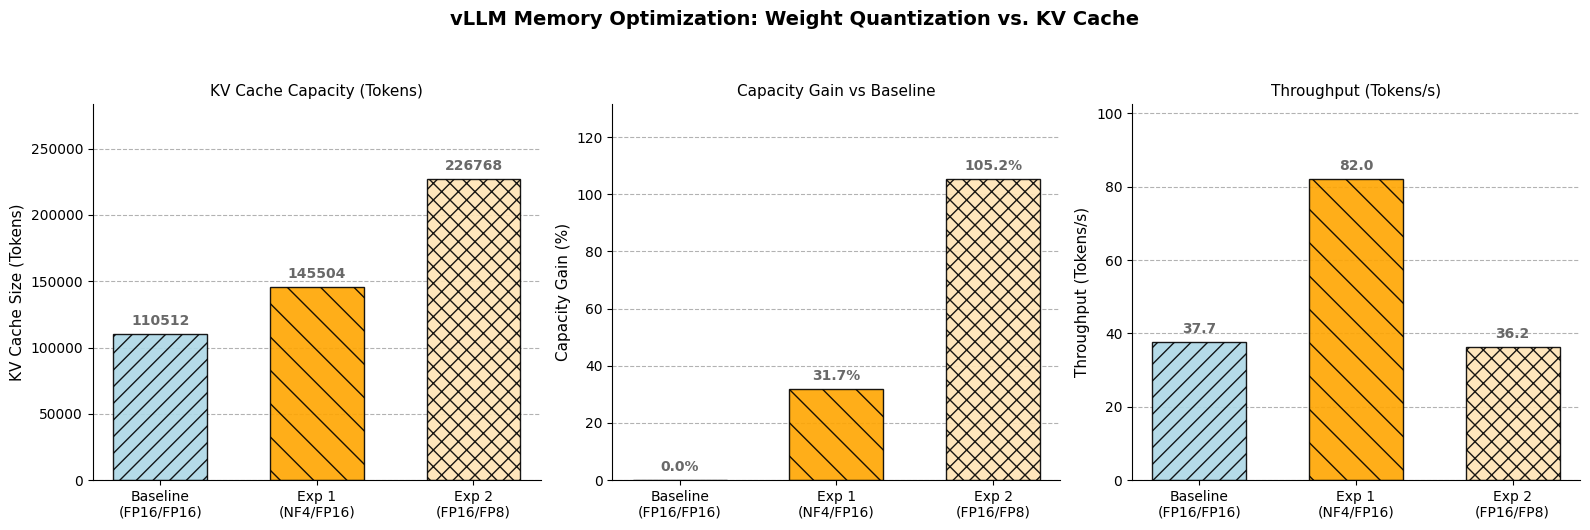

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

configurations = ['Baseline\n(FP16/FP16)', 'Exp 1\n(NF4/FP16)', 'Exp 2\n(FP16/FP8)']
kv_tokens_data = [kv_tokens_fp16, kv_tokens_nf4, kv_tokens_fp8]
cap_gain = [capacity_gain_fp16, capacity_gain_nf4, capacity_gain_fp8]
throughput_data = [throughput_fp16, throughput_nf4, throughput_fp8]

colors  = ['lightblue', 'orange', 'moccasin']
hatches = ['//', '\\', 'xx']
x = np.arange(len(configurations))
width = 0.6

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')

panels = [
    (axes[0], kv_tokens_data, 'KV Cache Size (Tokens)', 'KV Cache Capacity (Tokens)', '{:.0f}'),
    (axes[1], cap_gain, 'Capacity Gain (%)', 'Capacity Gain vs Baseline', '{:.1f}%'),
    (axes[2], throughput_data, 'Throughput (Tokens/s)', 'Throughput (Tokens/s)', '{:.1f}'),
]

for ax, values, ylabel, title, fmt in panels:
    ax.set_facecolor('white')
    max_val = max(values) if max(values) > 0 else 1

    for i, (val, color, hatch) in enumerate(zip(values, colors, hatches)):
        ax.bar(
            x[i], val, width,
            color=color, alpha=0.9,
            hatch=hatch, edgecolor='black'
        )
        ax.text(
            x[i], val + max_val * 0.02,
            fmt.format(val),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='dimgray'
        )

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(configurations, fontsize=10)
    ax.set_ylim(0, max_val * 1.25) # Add headroom for labels
    ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='gray')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('vLLM Memory Optimization: Weight Quantization vs. KV Cache',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

These tests evaluate two memory optimizations in vLLM. Because vLLM pre-allocates a fixed percentage of GPU memory at startup, any VRAM saved from the model or cache automatically increases the available KV tokens (capacity).

KV Cache Quantization (FP8): Changing the cache from 2-byte FP16 to 1-byte FP8 roughly doubles the pre-allocated KV tokens. Unlike tests on older hardware (see CH08_NB02_T4_KVCache_vLLM.ipynb), throughput remains almost identical to the baseline. The L4 GPU features native FP8 acceleration, allowing vLLM to handle quantization with essentially zero computational overhead.

Weight Quantization (NF4): Compressing the 3B model's weights to 4-bit NormalFloat frees significant static VRAM, which vLLM automatically converts into extra KV cache capacity. Additionally, because LLM inference is memory-bound, smaller weights transfer faster across the GPU's memory bus, noticeably increasing generation throughput.

Conclusion: FP8 effectively doubles context capacity without speed loss on modern GPUs, while NF4 accelerates inference and provides a secondary capacity boost by shrinking the model footprint.